In [4]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


In [5]:
# =========================
# DEFINICIÓN DE LA CLASE ELM
# (NECESARIA PARA joblib.load)
# =========================

import numpy as np

class ELM:
    def __init__(self, input_dim, hidden_dim, output_dim, activation, reg):
        self.W = None
        self.b = None
        self.beta = None
        self.activation_name = activation
        self.reg = reg

        if activation == "tanh":
            self.activation = np.tanh
        elif activation == "relu":
            self.activation = lambda x: np.maximum(0, x)
        else:
            self.activation = lambda x: 1 / (1 + np.exp(-x))

    def fit(self, X, T):
        H = self.activation(X @ self.W + self.b)
        I = np.eye(H.shape[1])
        self.beta = np.linalg.inv(H.T @ H + self.reg * I) @ H.T @ T

    def predict(self, X):
        H = self.activation(X @ self.W + self.b)
        return np.argmax(H @ self.beta, axis=1)


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [7]:
DATASET_DIR = Path("dataset_split")


In [8]:
transform_test = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [9]:
test_ds = datasets.ImageFolder(
    root=DATASET_DIR / "test",
    transform=transform_test
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,      # 1 imagen a la vez (para visualizar)
    shuffle=False
)

class_names = test_ds.classes
print("Clases:", class_names)
print("Total imágenes test:", len(test_ds))


Clases: ['Aedes aegypti', 'Culex quinquefasciatus']
Total imágenes test: 120


In [10]:
x, y = next(iter(test_loader))
print(x.shape)
print("Label:", y.item(), "->", class_names[y.item()])


torch.Size([1, 3, 384, 384])
Label: 0 -> Aedes aegypti


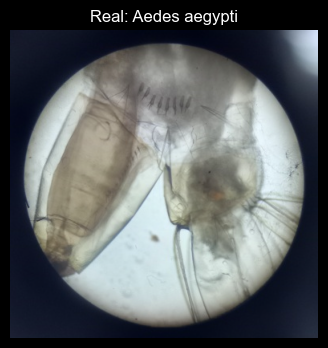

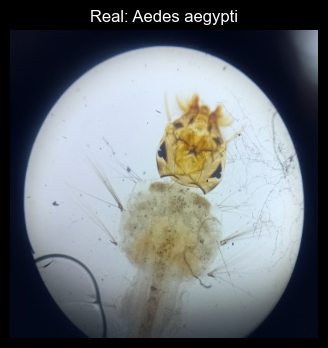

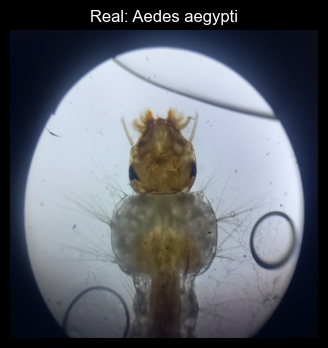

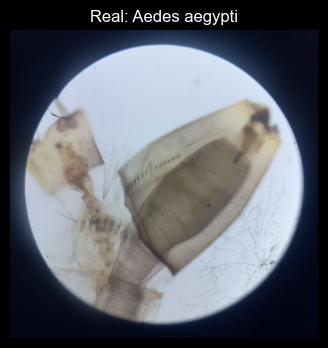

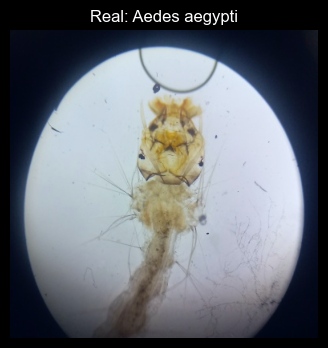

In [11]:
num_images = 5
count = 0

for x, y in test_loader:
    if count >= num_images:
        break

    x = x.to(device)
    y = y.item()

    plt.figure(figsize=(4,4))
    img = x.cpu().squeeze().permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img)
    plt.title(f"Real: {class_names[y]}")
    plt.axis("off")
    plt.show()

    count += 1


In [12]:
from models.cnn import CNNPure


In [13]:
CNN_MODEL_PATH = Path("results/cnn/cnn_pure.pth")


In [14]:
cnn_model = CNNPure(num_classes=2).to(device)
cnn_model.load_state_dict(torch.load(CNN_MODEL_PATH, map_location=device))
cnn_model.eval()

print("CNN cargado correctamente")


CNN cargado correctamente


In [15]:
x, y = next(iter(test_loader))
x = x.to(device)

with torch.no_grad():
    outputs = cnn_model(x)
    pred = outputs.argmax(1).item()

print("Clase real:", class_names[y.item()])
print("Predicción CNN:", class_names[pred])


Clase real: Aedes aegypti
Predicción CNN: Aedes aegypti


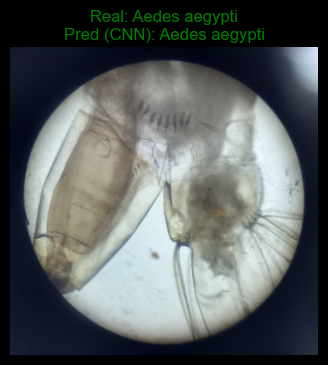

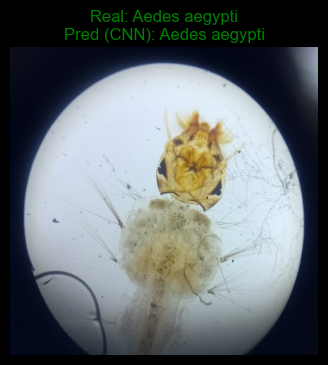

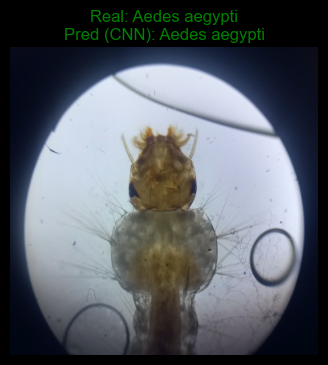

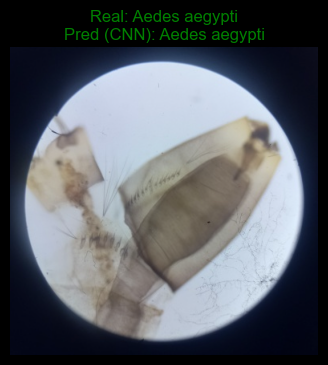

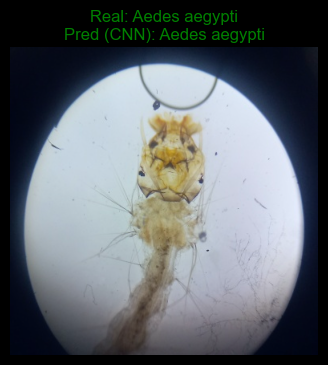

In [16]:
num_images = 5
count = 0

for x, y in test_loader:
    if count >= num_images:
        break

    x = x.to(device)
    y_true = y.item()

    with torch.no_grad():
        outputs = cnn_model(x)
        y_pred = outputs.argmax(1).item()

    # Imagen
    img = x.cpu().squeeze().permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(
        f"Real: {class_names[y_true]}\n"
        f"Pred (CNN): {class_names[y_pred]}",
        color="green" if y_true == y_pred else "red"
    )
    plt.axis("off")
    plt.show()

    count += 1


In [17]:
import joblib
from pathlib import Path

ELM_MODEL_PATH = Path("results/elm/cnn_elm.pkl")


In [18]:
elm = joblib.load(ELM_MODEL_PATH)
print("ELM cargado correctamente")


ELM cargado correctamente


In [19]:
def predict_cnn_elm(cnn_model, elm_model, x):
    """
    Predicción usando CNN como extractor + ELM como clasificador
    """
    with torch.no_grad():
        feats = cnn_model.features(x)          # (1, 256)
        feats = feats.view(feats.size(0), -1)  # flatten
        feats_np = feats.cpu().numpy()

        pred = elm_model.predict(feats_np)[0]

    return pred


In [20]:
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img.permute(1, 2, 0).cpu().numpy()
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img


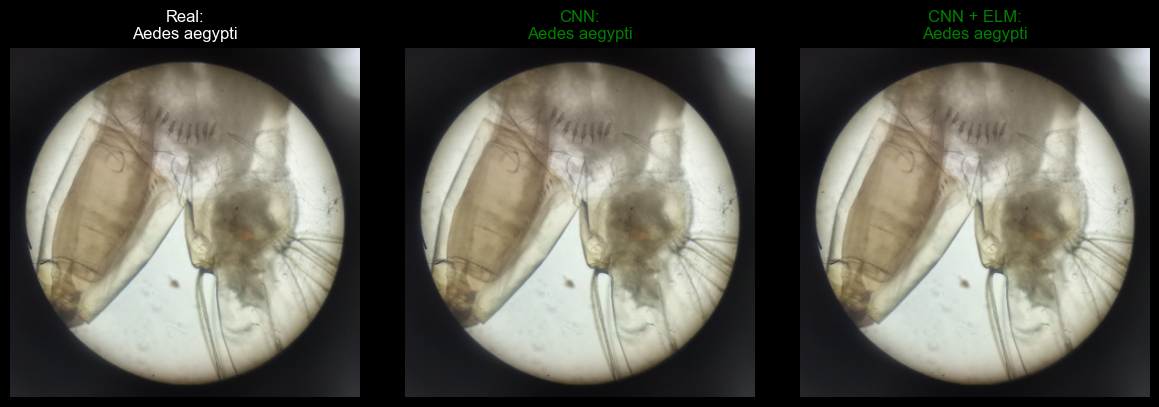

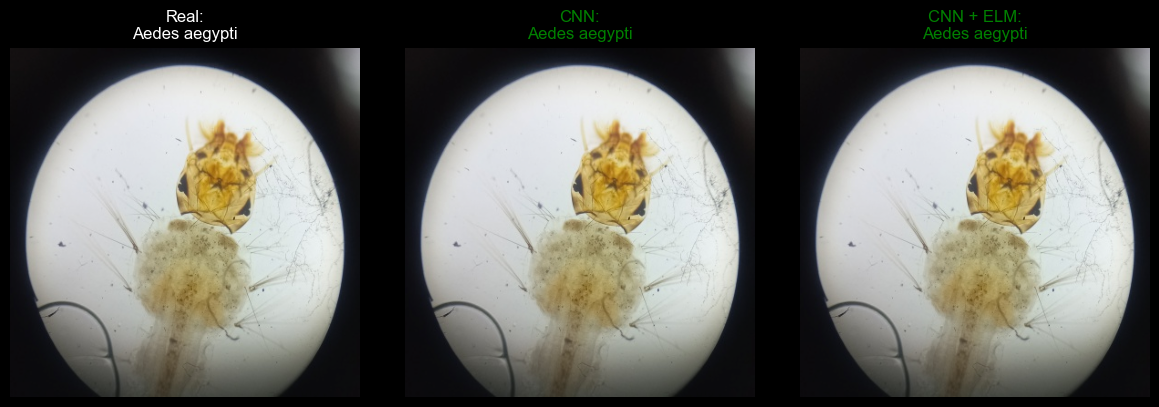

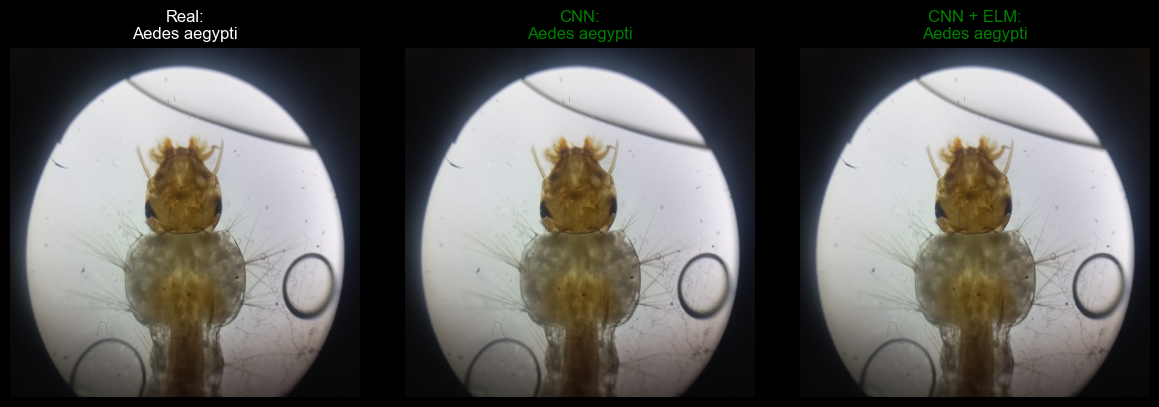

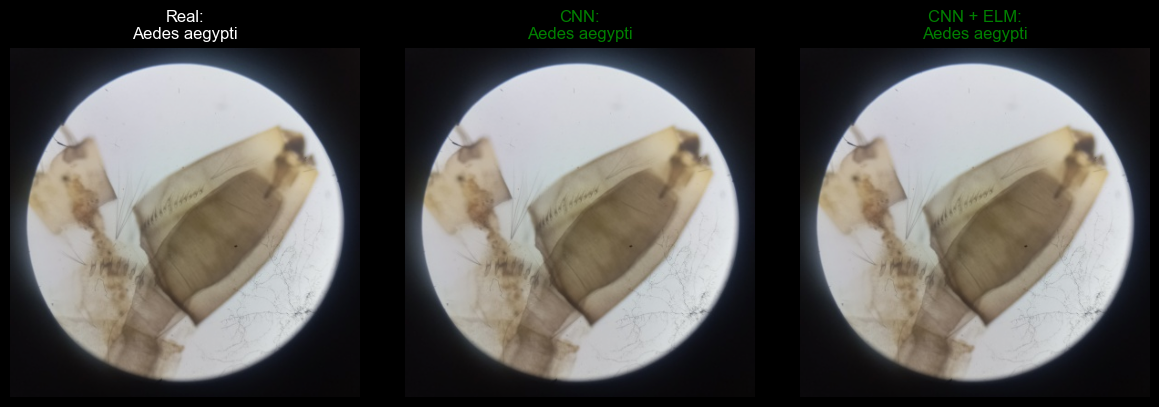

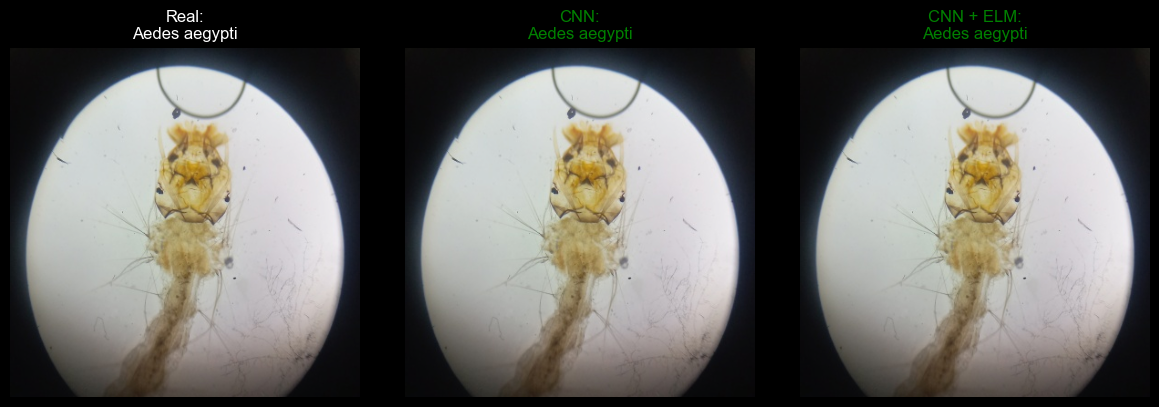

In [21]:
num_images = 5
count = 0

for x, y in test_loader:
    if count >= num_images:
        break

    x = x.to(device)
    y_true = y.item()

    # Predicción CNN
    with torch.no_grad():
        out = cnn_model(x)
        y_pred_cnn = out.argmax(1).item()

    # Predicción CNN + ELM
    y_pred_elm = predict_cnn_elm(cnn_model, elm, x)

    # Imagen para mostrar
    img = denormalize(x[0])

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    # REAL
    axs[0].imshow(img)
    axs[0].set_title(f"Real:\n{class_names[y_true]}")
    axs[0].axis("off")

    # CNN
    axs[1].imshow(img)
    axs[1].set_title(
        f"CNN:\n{class_names[y_pred_cnn]}",
        color="green" if y_pred_cnn == y_true else "red"
    )
    axs[1].axis("off")

    # CNN + ELM
    axs[2].imshow(img)
    axs[2].set_title(
        f"CNN + ELM:\n{class_names[y_pred_elm]}",
        color="green" if y_pred_elm == y_true else "red"
    )
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

    count += 1
